In [2]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

1) Loading in Data

In [3]:
train = pd.read_csv(r"C:\Users\bryan\OneDrive\LSTM MODEL\data\store-sales-time-series-forecasting\train.csv")
type(train)
train.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


2) Data Exploration

In [4]:
train.shape #Tells us (row, columns)

(3000888, 6)

In [5]:
train.columns # Tells us the names of all the columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

In [6]:
train.info() # Tells us datatype for each column

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [7]:
train["date"] = pd.to_datetime(train["date"]) # Swtiching the data to actual data instead of being a string

In [8]:
train.isnull().sum() # How many missing values are in each column

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [9]:
train["store_nbr"].nunique() # How many unique stores are in the dataset

54

In [10]:
train["family"].nunique() # How many unique different products there are in the dataset

33

In [11]:
train["date"].min() # Earliest date in the dataset

Timestamp('2013-01-01 00:00:00')

In [12]:
train["date"].max() # The most recent date in the dataset

Timestamp('2017-08-15 00:00:00')

In [13]:
train["sales"].describe() # Tells us important stuff like mean,std,min,max, etx.

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [14]:
train.nlargest(10, "sales")[["date", "store_nbr", "family", "sales", "onpromotion"]]

,date,store_nbr,family,sales,onpromotion
2163723,2016-05-02,2,GROCERY I,124717.000,59
2445984,2016-10-07,39,MEATS,89576.360,0
2144154,2016-04-21,20,GROCERY I,87438.516,53
2139699,2016-04-18,45,GROCERY I,76090.000,38
2153031,2016-04-26,2,GROCERY I,63434.000,30
2145045,2016-04-21,45,GROCERY I,53874.000,44
562596,2013-11-12,44,GROCERY I,46271.000,0
1257246,2014-12-08,35,GROCERY I,45361.000,3
1916586,2015-12-14,35,GROCERY I,40351.460,7
2760297,2017-04-02,9,GROCERY I,38422.625,73


In [15]:
train.loc[train["sales"].idxmax()]

id                         2163723
date           2016-05-02 00:00:00
store_nbr                        2
family                   GROCERY I
sales                     124717.0
onpromotion                     59
Name: 2163723, dtype: object

In [16]:
train[
    (train["store_nbr"] == 2) &
    (train["family"] == "GROCERY I") &
    (train["date"].between("2016-04-25", "2016-05-09"))
][["date", "sales", "onpromotion"]]

,date,sales,onpromotion
2151249,2016-04-25,3552.0,31
2153031,2016-04-26,63434.0,30
2154813,2016-04-27,2213.0,64
2156595,2016-04-28,3023.0,61
2158377,2016-04-29,3940.0,57
2160159,2016-04-30,5466.0,66
2161941,2016-05-01,6768.0,68
2163723,2016-05-02,124717.0,59
2165505,2016-05-03,4323.0,75
2167287,2016-05-04,4467.0,64


In [17]:
(train["sales"] > 10000).sum()

np.int64(6017)

In [18]:
(train["sales"] > 50000).sum()

np.int64(6)

In [19]:
(train["sales"] > 1000000).sum()

np.int64(0)

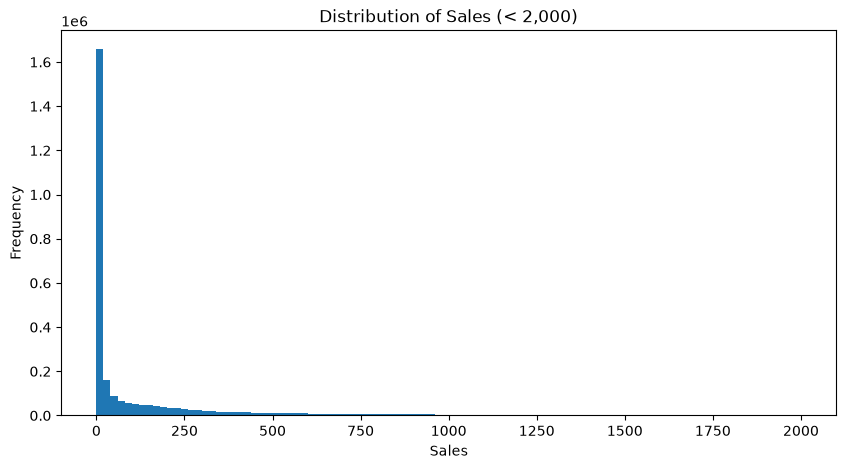

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    train.loc[train["sales"] < 2000, "sales"],
    bins=100
)

plt.title("Distribution of Sales (< 2,000)")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show() #Histogram

In [21]:
daily_sales = train.groupby("date")["sales"].sum()

In [22]:
daily_sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

In [23]:
daily_sales.shape

(1684,)

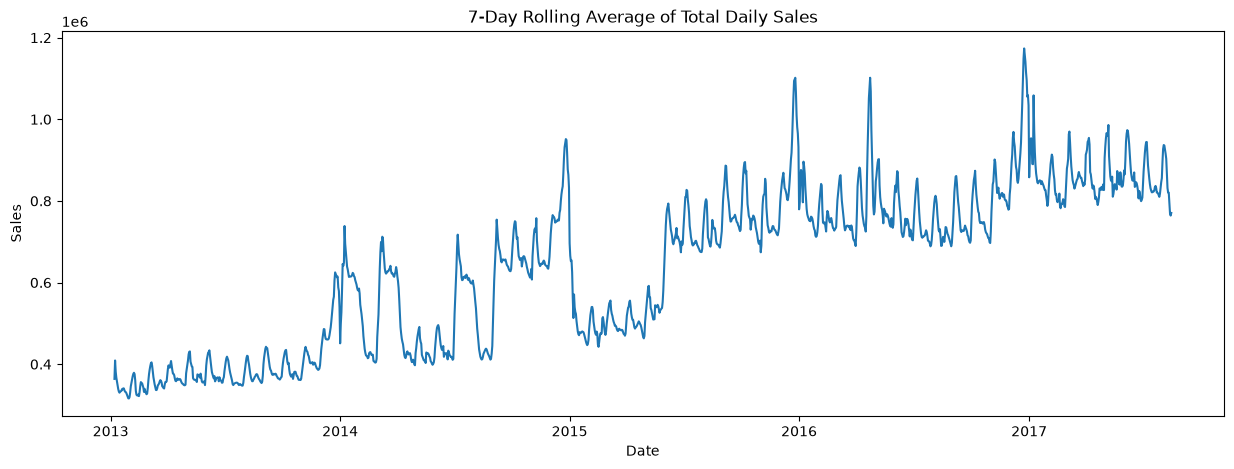

In [24]:
weekly_trend = daily_sales.rolling(7).mean()

plt.figure(figsize=(15, 5))

plt.plot(weekly_trend.index, weekly_trend.values)

plt.title("7-Day Rolling Average of Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [25]:
train["date"] = pd.to_datetime(train["date"])

In [26]:
train["day_of_week"] = train["date"].dt.day_name()

In [27]:
dow_sales = train.groupby("day_of_week")["sales"].mean()

In [28]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_sales = dow_sales.reindex(day_order)
dow_sales

day_of_week
Monday       346.544732
Tuesday      319.823843
Wednesday    332.909401
Thursday     283.540517
Friday       325.238138
Saturday     433.336472
Sunday       463.085366
Name: sales, dtype: float64

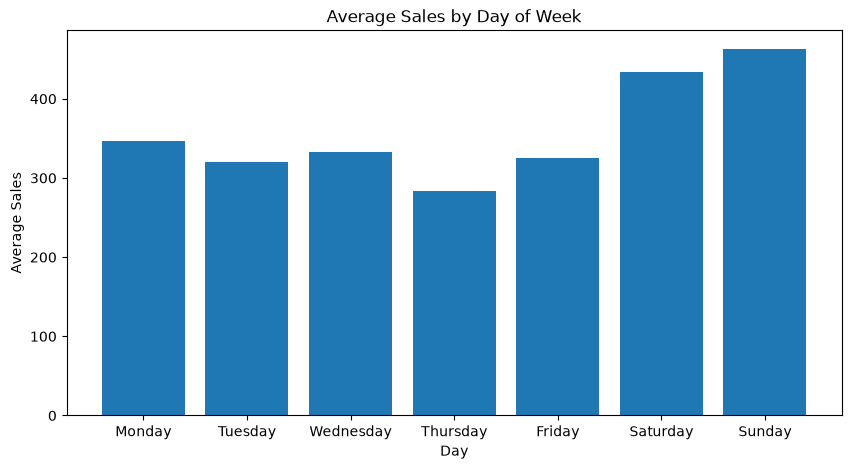

In [29]:
plt.figure(figsize=(10, 5))

plt.bar(dow_sales.index, dow_sales.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.show()

In [30]:
train["month"] = train["date"].dt.month

In [31]:
monthly_sales = train.groupby("month")["sales"].mean()

monthly_sales

month
1     341.921554
2     320.928869
3     352.009294
4     339.199841
5     341.765820
6     353.597842
7     374.219111
8     336.992535
9     362.297418
10    362.407132
11    375.681762
12    453.740370
Name: sales, dtype: float64

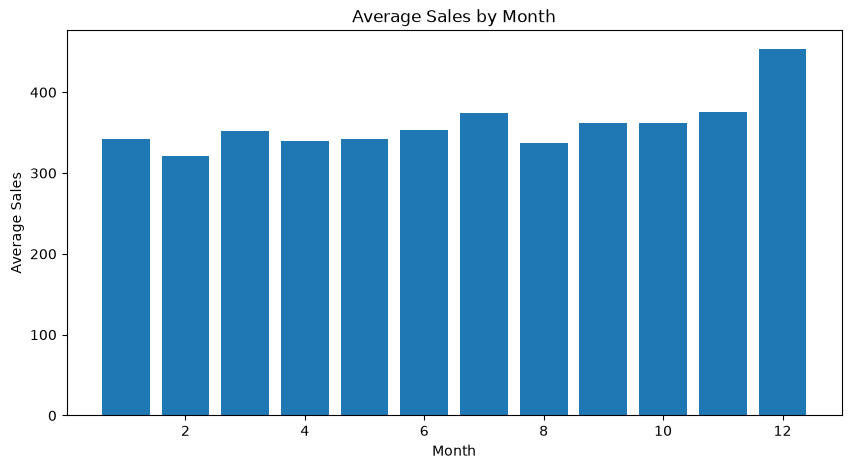

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

In [33]:
daily_df = daily_sales.reset_index(name="sales")

In [34]:
daily_df["date"] = pd.to_datetime(daily_df["date"])

In [35]:
daily_df["day_of_week"] = daily_df["date"].dt.day_name()

In [36]:
daily_df.head()

,date,sales,day_of_week
0,2013-01-01,2511.618999,Tuesday
1,2013-01-02,496092.417944,Wednesday
2,2013-01-03,361461.231124,Thursday
3,2013-01-04,354459.677093,Friday
4,2013-01-05,477350.121229,Saturday


7) Forecasting Target (Sales for every weekday)

In [37]:
daily_dow = daily_df.groupby("day_of_week")["sales"].mean()

daily_dow = daily_dow.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(daily_dow)

day_of_week
Monday       617542.713052
Tuesday      569926.087922
Wednesday    593244.553472
Thursday     505269.201115
Friday       579574.361085
Saturday     772205.593943
Sunday       825218.121579
Name: sales, dtype: float64


8) Chronological Split (Test, Train, Validation)

In [38]:
print("Start date:", daily_sales.index.min())
print("End date:", daily_sales.index.max())
print("Number of days:", len(daily_sales))

Start date: 2013-01-01 00:00:00
End date: 2017-08-15 00:00:00
Number of days: 1684


In [39]:
n = len(daily_sales)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

print("Total days:", n)
print("Training days:", train_end)
print("Validation days:", val_end - train_end)
print("Test days:", n - val_end)

Total days: 1684
Training days: 1347
Validation days: 168
Test days: 169


In [40]:
train_data = daily_sales.iloc[:train_end]
val_data = daily_sales.iloc[train_end:val_end]
test_data = daily_sales.iloc[val_end:]

In [41]:
print("TRAIN")
print(train_data.index.min(), "→", train_data.index.max())

print("\nVALIDATION")
print(val_data.index.min(), "→", val_data.index.max())

print("\nTEST")
print(test_data.index.min(), "→", test_data.index.max())

TRAIN
2013-01-01 00:00:00 → 2016-09-11 00:00:00

VALIDATION
2016-09-12 00:00:00 → 2017-02-27 00:00:00

TEST
2017-02-28 00:00:00 → 2017-08-15 00:00:00


In [42]:
print("Training:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Training: 1347
Validation: 168
Test: 169


In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [46]:
scaler.fit(train_data.values.reshape(-1, 1))

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[1345920.6]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[2511.62]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[1343408.99]
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1347
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](1,)",[0.]


In [47]:
train_scaled = scaler.transform(train_data.values.reshape(-1, 1))
val_scaled = scaler.transform(val_data.values.reshape(-1, 1))
test_scaled = scaler.transform(test_data.values.reshape(-1, 1))